# Customer Churn Analysis - Exploratory Data Analysis

Objective:
Identify factors that contribute to customer churn and generate actionable business insights.

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Load Cleaned Dataset

In [6]:
df = pd.read_csv("../data/cleaned/churn_cleaned.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Dataset Overview

In [7]:
df.shape

(7043, 21)

The dataset contains 7,043 customer records and 21 features.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


## 1. Overall Customer Churn Analysis

### Business Objective
Before identifying the drivers of churn, it is important to understand the overall churn situation within the company.

### Key Question
What percentage of customers have discontinued the service?

### Why It Matters
The churn rate serves as a key business KPI and helps measure customer retention performance. A high churn rate may indicate issues related to pricing, service quality, customer satisfaction, or competitive pressure.

In [10]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [11]:
churn_rate = (
    df["Churn"]
    .value_counts(normalize=True)
    *100
)

churn_rate

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

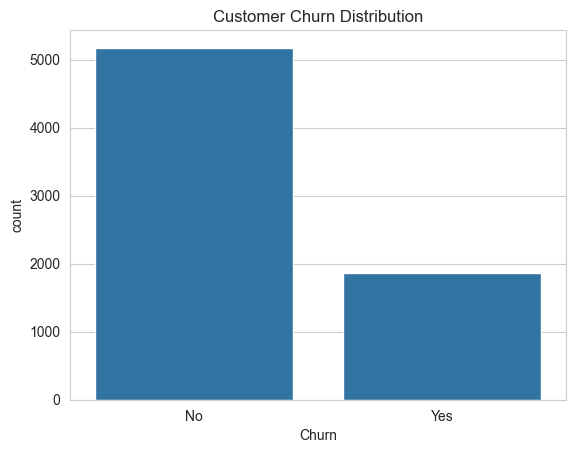

In [12]:
sns.countplot(
    x="Churn",
    data=df
)

plt.title("Customer Churn Distribution")

plt.show()

## 2. Churn Analysis by Gender

### Business Objective
Evaluate whether customer churn varies across gender groups.

### Key Question
Do male and female customers exhibit different churn behavior?

### Why It Matters
Understanding demographic differences can help businesses design targeted retention strategies and marketing campaigns if significant variations exist.

In [13]:
pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
)*100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


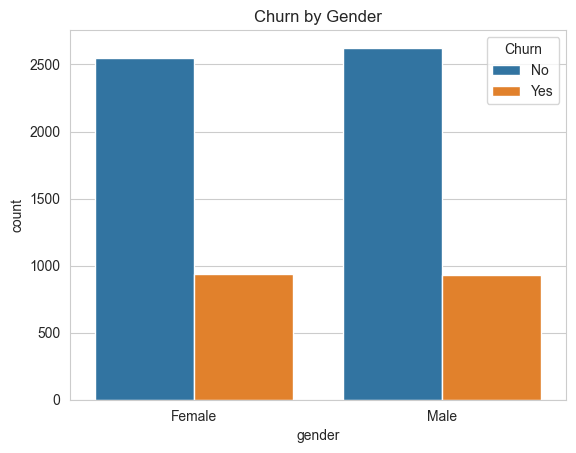

In [14]:
sns.countplot(
    x="gender",
    hue="Churn",
    data=df
)

plt.title("Churn by Gender")

plt.show()

## 3. Impact of Contract Type on Customer Churn

### Business Objective
Analyze how different contract types influence customer retention.

### Key Question
Which contract type experiences the highest customer churn?

### Why It Matters
Contract structure often impacts customer loyalty. Identifying high-risk contract categories can help the business develop incentives for long-term customer commitment.

In [15]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
)*100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


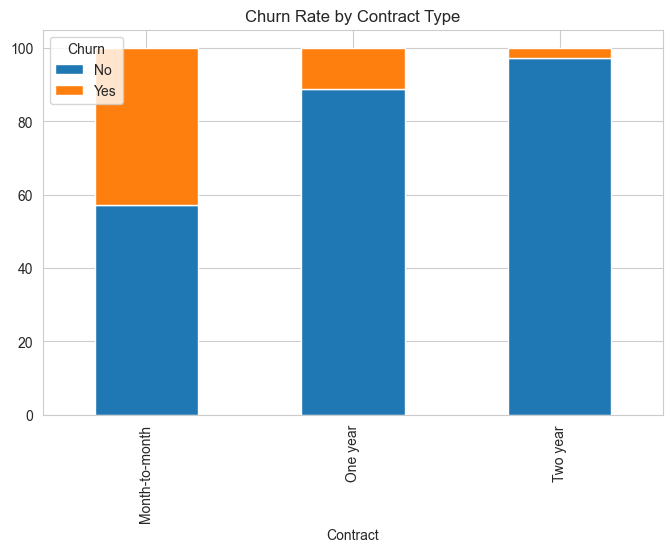

In [16]:
contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Churn Rate by Contract Type")

plt.show()

## 4. Churn Analysis by Payment Method

### Business Objective
Examine whether payment methods are associated with customer churn.

### Key Question
Which payment methods have the highest churn rates?

### Why It Matters
The payment experience can significantly impact customer satisfaction. Identifying problematic payment channels can help improve customer retention.

In [17]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
)*100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


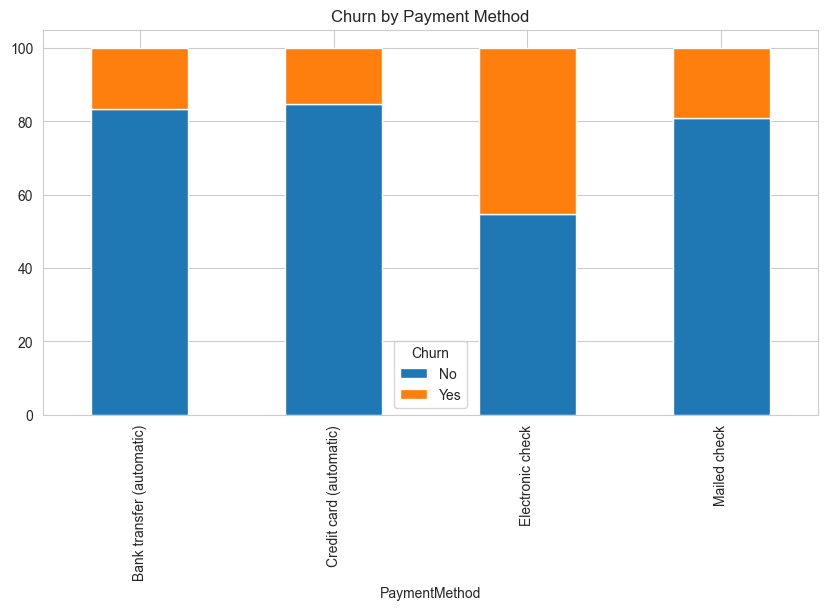

In [18]:
payment_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5)
)

plt.title("Churn by Payment Method")

plt.show()

## 5. Impact of Internet Service Type on Churn

### Business Objective
Determine whether the type of internet service affects customer churn behavior.

### Key Question
Which internet service category experiences the highest churn rate?

### Why It Matters
Service quality, pricing, and customer expectations often vary across service types. Understanding these differences can help prioritize service improvements.


In [19]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
)*100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


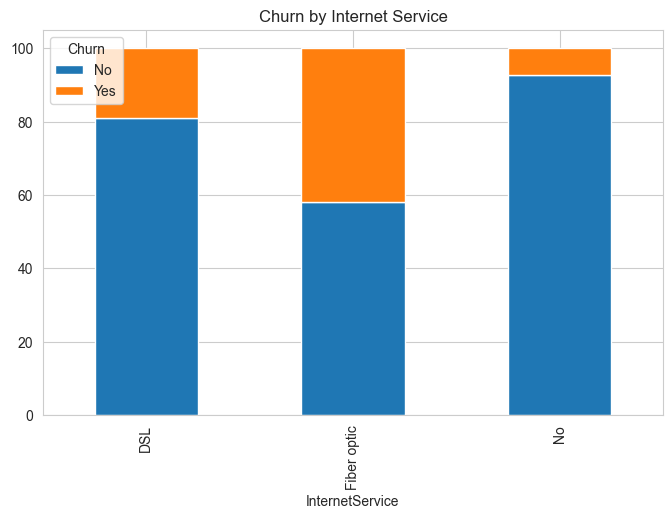

In [20]:
internet_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Churn by Internet Service")

plt.show()

## 6. Relationship Between Monthly Charges and Churn

### Business Objective
Investigate whether pricing influences customer retention.

### Key Question
Are customers with higher monthly charges more likely to churn?

### Why It Matters
Pricing is a major factor affecting customer decisions. If higher-paying customers are leaving, the company may need to reassess pricing strategies or improve value perception.

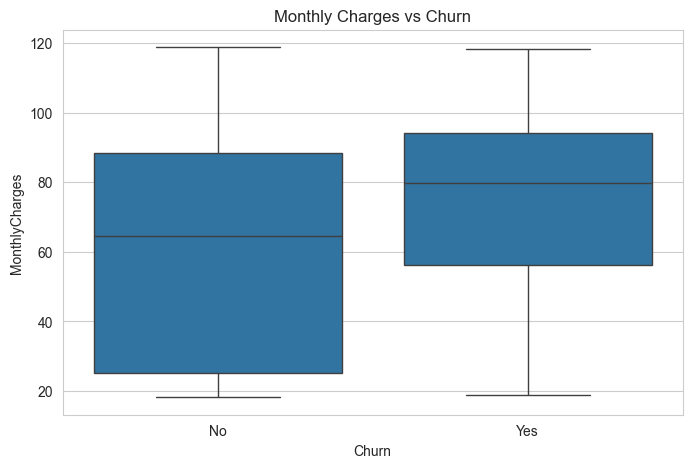

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.show()

## 7. Customer Tenure and Churn Behavior

### Business Objective
Analyze how the length of customer relationship affects churn.

### Key Question
Are newer customers more likely to churn than long-term customers?

### Why It Matters
Understanding churn across customer lifecycles helps businesses focus retention efforts during critical stages of the customer journey.

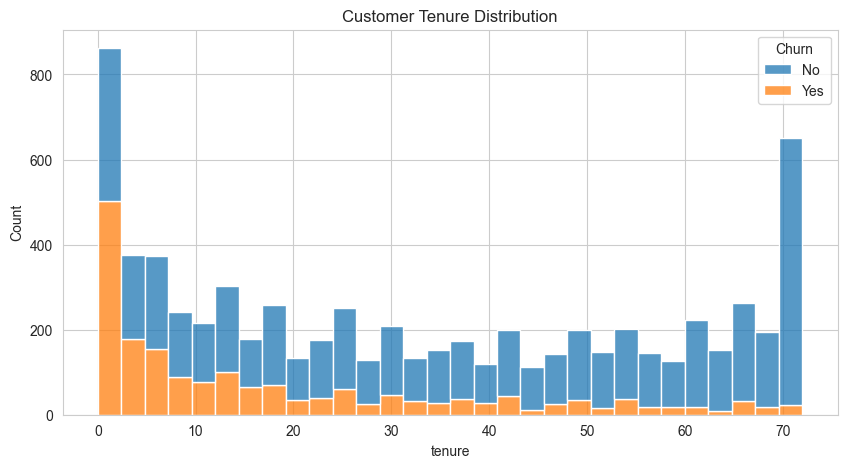

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    multiple="stack"
)

plt.title("Customer Tenure Distribution")

plt.show()

## 8. Churn Analysis Among Senior Citizens

### Business Objective
Evaluate whether senior citizens demonstrate different churn behavior compared to other customers.

### Key Question
Is churn higher among senior citizen customers?

### Why It Matters
Different age groups may have unique service expectations and support requirements. Understanding these patterns can guide customer experience improvements.

In [23]:
pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
)*100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


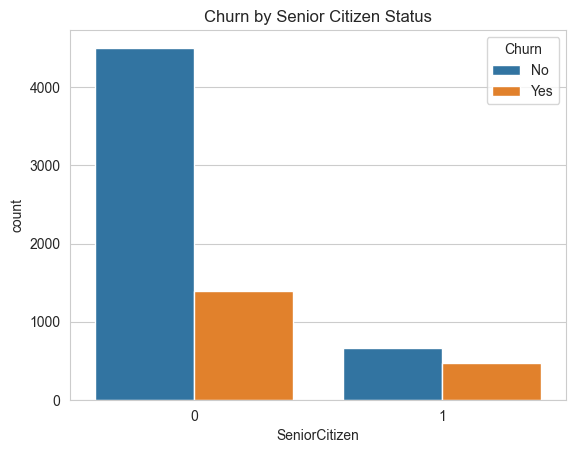

In [24]:
sns.countplot(
    x="SeniorCitizen",
    hue="Churn",
    data=df
)

plt.title("Churn by Senior Citizen Status")

plt.show()

# Executive Summary

## Key Findings

- Approximately 27% of customers have churned.
- Month-to-month contracts exhibit the highest churn rates.
- Customers using electronic check payments are more likely to leave.
- Fiber optic customers demonstrate elevated churn behavior.
- Higher monthly charges are associated with increased churn risk.
- Customers with shorter tenure are significantly more likely to churn.
- Gender does not appear to have a substantial impact on churn.
- Certain customer segments require targeted retention strategies.

## Business Recommendations

1. Encourage customers to transition from month-to-month contracts to annual plans through incentives and discounts.

2. Improve onboarding experiences for new customers to reduce early-stage churn.

3. Investigate the customer experience associated with electronic check payments.

4. Evaluate pricing strategies for customers with high monthly charges.

5. Develop proactive retention programs for high-risk customer segments identified during the analysis.

## Conclusion

Customer churn is influenced by multiple factors including contract type, tenure, pricing, and service characteristics. By focusing on high-risk customer groups and implementing targeted retention initiatives, the company can improve customer loyalty and reduce revenue loss.